# PR13 · Design a temporal filter using actual sampling

<!-- paper-first -->
### Research question

**Reading:** [PP02](../../curriculum/papers/processing.md#pp02), [PB01](../../curriculum/papers/measurement.md#pb01). Review the assigned figure or result before starting the lesson.

**Question:** Could a filter remove part of the signal whose biological meaning you want to study?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Derive sampling and Nyquist frequencies from TR.
- Inspect filter response and edge behavior.
- Explain aliasing and why run boundaries require separate treatment.

## Understand the operation

A sampled time series contains variation at several time scales. A high-pass attenuates slow components, a low-pass attenuates faster components, and a band-pass combines both. Real filters have transition regions; they do not perfectly sort neuronal and non-neuronal signals. A slow task effect can overlap a proposed high-pass, while physiological effects can enter lower bands through sampling and aliasing.

TR determines sampling frequency as1/TR. Nyquist is half that frequency. At TR2 seconds, these are.5Hz and.25Hz. A0.35Hz sinusoid sampled on this grid aliases into a lower-frequency pattern, so a later filter cannot simply identify its original physical frequency from those samples. Knowing acquisition timing and any physiological recordings matters.

The lab uses a Butterworth filter in second-order-section form, applied forward and backward for offline zero-phase processing. This uses future samples and changes the magnitude response relative to one pass; it is not an unchanged real-time algorithm. Boundary padding and run length affect the result. Independent runs must be treated with their own temporal models rather than concatenated into a fictitious continuous recording. Likewise, deleting censored frames and pretending the original TR still applies changes the time grid. Cutoffs should be chosen in relation to the design and target analysis, then checked together with confound modeling. The numerical band below is illustrative, not a universal resting-state or task recommendation.

## Transformation contract

**Input:** evenly sampled series, TR, cutoffs and boundary policy. **Output:** filtered values on the same sample grid. **Preserved:** positions and selected frequency content approximately. **Changed:** amplitude, dependence and edge values. **Not recovered:** aliased information or independent observations lost through filtering.


## Read the actual course material

- [DartBrains: Signal Processing, Fourier analysis and filters](https://github.com/ljchang/dartbrains/blob/5d727f7a72a7f20bfb32603cac8509d78b9647f2/content/Signal_Processing.py). CC BY-SA 4.0; linked pinned chapter.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Derive the filter sampling rate from TR. Measure retained amplitudes in a stated interior interval, inspect the full trace, and demonstrate aliasing with the two provided sinusoids. Do not call the retained band pure neuronal signal. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from scipy.signal import butter,sosfiltfilt
import matplotlib.pyplot as plt
TR=2.; t=np.arange(300)*TR
raw=2*np.sin(2*np.pi*.005*t)+np.sin(2*np.pi*.05*t)+.5*np.sin(2*np.pi*.18*t)
sos=butter(4,[.01,.1],btype='bandpass',fs=1/TR,output='sos')
filtered=sosfiltfilt(sos,raw)
wrong=sosfiltfilt(butter(4,[.01,.1],btype='bandpass',fs=1.,output='sos'),raw)
ix=slice(50,-50)
def amplitude(y,f):
    phase=2*np.pi*f*t[ix]; X=np.column_stack([np.sin(phase),np.cos(phase),np.ones(200)])
    return np.linalg.norm(np.linalg.lstsq(X,y[ix],rcond=None)[0][:2])
a=[amplitude(filtered,f) for f in [.005,.05,.18]]
print('retained amplitudes:',a,'wrong TR target:',amplitude(wrong,.05))
assert a[0]<.1 and a[1]>.9 and a[2]<.03 and amplitude(wrong,.05)<.65


retained amplitudes: [np.float64(0.008823191580961265), np.float64(0.9989885150066967), np.float64(0.00032293325354603494)] wrong TR target: 0.5077001507172441


At TR2s, these .35Hz and sign-reversed .15Hz samples are indistinguishable.


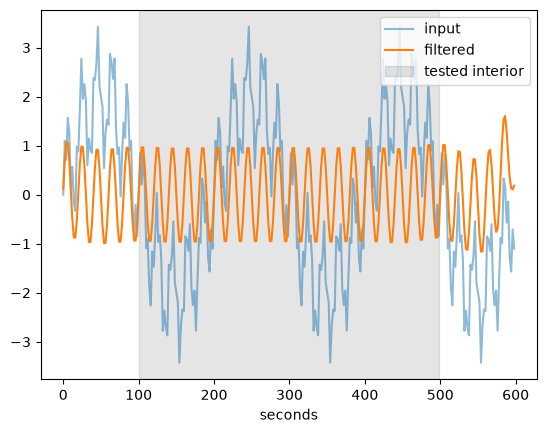

In [2]:
aliased=np.sin(2*np.pi*.35*t)
low_alias=-np.sin(2*np.pi*.15*t)
assert np.allclose(aliased,low_alias,atol=1e-12)
print('At TR2s, these .35Hz and sign-reversed .15Hz samples are indistinguishable.')
plt.plot(t,raw,alpha=.5,label='input'); plt.plot(t,filtered,label='filtered')
plt.axvspan(t[50],t[-51],alpha=.1,color='black',label='tested interior')
plt.xlabel('seconds'); plt.legend(); plt.show()


## Check and explain

The intended.05Hz component remains above.9 amplitude while the slow and fast components are attenuated. Using the wrong TR yields about.5 amplitude for the component of interest. The aliased pair matches to numerical precision despite different continuous frequencies.

## Deliberately wrong method

An incorrect sampling rate still produces valid arrays and attractive plots. Cutting out bad frames before an ordinary evenly sampled filter creates a different error. Explain the metadata/time-grid problem before proposing a software fix.

## Transfer to an actual dataset or tool — guided assignment

Work through the pinned DartBrains Fourier/filter sections and record the response of a justified temporal filter. For a real task run, overlay the design frequency content and check whether the intended effect is attenuated. For multiple runs, retain run boundaries and verify the package processes each separately. Add your exact cutoffs, TR, detrending, edge policy and censoring strategy to the provenance record. Real task-model choices belong with the design strand.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why can postprocessing fail to remove aliased physiology? **Answer:** different continuous signals can produce indistinguishable samples.
2. What does a smooth output prove? **Answer:** only that an operation changed the signal; it does not establish its origin or validity.


### Return to the research question

Revisit [PP02](../../curriculum/papers/processing.md#pp02), [PB01](../../curriculum/papers/measurement.md#pb01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
